##List of Homework's exercises:

1.   [Ex1](#scrollTo=ux5PBYkbwewj) - 2 points
2.   [Ex2](#scrollTo=Z5C3GX9eXFF_) - 4 points
3.   [Ex3](#scrollTo=uHQscVCD7rM0) - 4 points
4.   [Bonus 1](#scrollTo=iJeG56t9-jWI) - 1 point
5.   [Bonus 2](#scrollTo=cLoHOqAcu0Q9) - up to 3 points
6.   [Bonus 3](#scrollTo=jdZkblZW7bEp) - up to 3 points (based on quality of presentation)




---


## Homework exercise 1: implement and train a bagging classifier with 3 K-NN models as estimators (2 points)


<font color='red'> In this exercise you will need to use `classify_knn` function from the first practice session to train three different KNN models on three resamples of this dataset. </font>


# Homework #5

## Ensemble learning

This colaboratory contains Homework #5 of the Machine Learning course, which is due **April 4, midnight (23:59 EEST time)**. To complete the homework, extract **(File -> Download .ipynb)** and submit to the course webpage.


## Submission's rules:

1.   Please, submit only .ipynb that you extract from the Colaboratory.
2. Run your homework exercises before submitting (output should be present, preferably restart the kernel and press run all the cells).
3. Do not change the description of tasks in red (even if there is a typo|mistake|etc).
4. Please, make sure to avoid unnecessary long printouts.
5. Each task should be solved right under the question of the task and not elsewhere.
6. Solutions to both regular and bonus exercises should be submitted in one IPYNB file.

Please, steer clear of copying someone else's work. If you discuss assignments with anyone in the course, please, mention their names here:

Pooh

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
def create_random_2c_data (D, N):
  """
  Function create_random_2c_data generates two sets of D dimensional
  points (N points each), one for each class. The first set is sampled from D
  dimensional Gaussian distribution with mean 0 and standard deviation 1. The
  second set is generated from the distribution, with mean 1 and standard
  deviation 1.
  """
  # Generating N points for the first class
  mu_vec1 = np.zeros(D) # creates a vector of zeros, these are averages across each dimension
  cov_mat1 = np.eye(D) # creates a diagonal matrix of size D x D, all values except diagonal are 0
  class1_sample = np.random.multivariate_normal(mu_vec1, cov_mat1, N)

  # The same stuff as above, just averages are shifted into 1
  mu_vec2 = np.ones(D) # creates a vector of ones
  cov_mat2 = np.eye(D)
  class2_sample = np.random.multivariate_normal(mu_vec2, cov_mat2, N)

  # a lot of boring things....
  # gluing together two matrices generated above
  data = pd.DataFrame(np.concatenate((class1_sample, class2_sample)))

  # Create names for columns
  data.columns = [ 'x' + str(i) for i in (np.arange(D)+1)]

  # Create a class column
  data['class'] = np.concatenate((np.repeat(0, N), np.repeat(1, N)))

  # This is important for plotting and modelling
  data['class'] = data['class'].astype('category')

  return data

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
np.random.seed(2342347823) # random seed, this number was random, no need to build conspiracies around it

D = 2 # two dimensions
N = 100 # points per class

whole_data = create_random_2c_data(D, N)

# Randomly splitting data into train (60%) and validation (40%)
train, val = train_test_split(whole_data, random_state = 111, test_size = 0.40)

n_bootstraps = 3
np.random.seed(1111)

# creating resamples
resamples = [resample(train, n_samples = len(train), replace=True).index.values for i in range(n_bootstraps)]

# first resample
train_resample1 = train.loc[resamples[0]]

# second resample
train_resample2 = train.loc[resamples[1]]

# third resample
train_resample3 = train.loc[resamples[2]]

<font color='red'> Here, I just convert pandas DataFrame into Numpy arrays that are easier to use list comprehension mechanisms on. </font>

In [ ]:
train1 = np.asarray(train_resample1[['x1','x2']])
labels1 = np.asarray(train_resample1[['class']]).reshape((train_resample1.shape[0]))

train2 = np.asarray(train_resample2[['x1','x2']])
labels2 = np.asarray(train_resample2[['class']]).reshape((train_resample2.shape[0]))

train3 = np.asarray(train_resample3[['x1','x2']])
labels3 = np.asarray(train_resample3[['class']]).reshape((train_resample3.shape[0]))

val_points = np.asarray(val[['x1','x2']])
val_labels = np.asarray(val[['class']]).reshape((val.shape[0]))

<font color='red'>  **(Homework exercise 1- a)** Copy and adapt `classify_knn` function from the first homework and practice session to operate on 2D points. **(0.5 points)**</font>

In [ ]:
def dist(point1, point2): # function dist is also from the first practice session
  # sum of squared coordinate-wise differences under sqrt
  return(np.sqrt(np.sum((point2 - point1)**2)))

def classify_knn(val_point, k, train, labels):

  ##### YOUR CODE STARTS #####
  all_distances = np.apply_along_axis(dist, axis=1, arr=train, point2=val_point)
  nearest_neighbours = np.argsort(all_distances)[:k]
  predicted_classes = labels[nearest_neighbours]
  prediction = np.argmax(np.bincount(predicted_classes))
  ##### YOUR CODE ENDS #####

  return prediction

<font color='red'> Test that the function was adapted correctly by running the following example </font>

In [ ]:
val_point = val_points[1]
print(f'predicted class of the first point is {classify_knn(val_point, 5,  train1, labels1)}, while the true class is {val_labels[1]}')

predicted class of the first point is 0, while the true class is 0


<font color='red'> **(Homework exercise 1- b)** Classify each point from the validation set using `classify_knn` function. Use different resamples and list comprehension. Fix `k` at 5. **(1 point)**</font>


In [ ]:
k = 5

# Use three K-NN models that work on three different resamples

##### YOUR CODE STARTS #####
val['knn1'] = [classify_knn(p, k, train1, labels1) for p in val_points]
val['knn2'] = [classify_knn(p, k, train2, labels2) for p in val_points]
val['knn3'] = [classify_knn(p, k, train3, labels3) for p in val_points]
##### YOUR CODE ENDS #####

<font color='red'> Below aggregate individual predictions using the majority vote approach</font>

In [ ]:
##### YOUR CODE STARTS #####
val['knn_bagging'] = val[['knn1', 'knn2', 'knn3']].mode(axis =1)
##### YOUR CODE ENDS #####

print(f"Accuracy of hand made bagged ensemble with 3 KNNs is {np.sum(val['knn_bagging'] == val['class'])/len(val[['class']])*100}%")

Accuracy of hand made bagged ensemble with 3 KNNs is 66.25%


Why not 67?

<font color='red'> **(Homework exercise 1- c)** Use sklearn `BaggingClassifier` to implement analogous model that uses KNeighborsClassifier as an estimator (with k = 5). Don't forget to use a random state for reproducibility.

Assess its performance on the same validation set and display it. **(0.5 points)**</font>


In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier

##### YOUR CODE STARTS #####
knn = KNeighborsClassifier(n_neighbors=5)
knn_begger = BaggingClassifier(estimator=knn, n_estimators=10, random_state=42)
knn_begger.fit(train[['x1','x2']], train['class'])
knn_begger.predict(val[['x1','x2']])
##### YOUR CODE ENDS #####
print(f"Accuracy of sklearn bagging with {3} KNNs {knn_begger.score(val[['x1', 'x2']], val[['class']])*100}%")

Accuracy of sklearn bagging with 3 KNNs 75.0%


## Homework exercise 2: eXtreme Gradient Boosting (XGBoost) (4 points)

<font color='red'> Let's finally build for ourselves a new shiny XGBoost model, the most popular algorithm for Kaggle competitions. </font>
<font color='red'>  Since XGBoost truly shines on tabular data, we are going to use the Thyroid Disease Dataset for training an XGboost model. Further details about this dataset can be found at
 [here](https://www.openml.org/search?type=data&status=active&id=40475). </font>


In [ ]:
from sklearn.datasets import fetch_openml

data = fetch_openml(name="thyroid-allhyper")

In [ ]:
#Let's take a look at data
data.data

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26
0,41.0,1,1,1,1,1,1,1,1,1,...,2,1.30000,2,2.500000,2,125.0,2,1.140000,2,109.000000
1,23.0,1,1,1,1,1,1,1,1,1,...,2,4.10000,2,2.000000,2,102.0,1,0.997912,1,110.787984
2,46.0,2,1,1,1,1,1,1,1,1,...,2,0.98000,1,2.024966,2,109.0,2,0.910000,2,120.000000
3,70.0,1,2,1,1,1,1,1,1,1,...,2,0.16000,2,1.900000,2,175.0,1,0.997912,1,110.787984
4,70.0,1,1,1,1,1,1,1,1,1,...,2,0.72000,2,1.200000,2,61.0,2,0.870000,2,70.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,70.0,2,1,1,1,1,1,1,1,1,...,2,2.70000,1,2.024966,2,155.0,2,1.050000,2,148.000000
2796,73.0,2,1,2,1,1,1,1,1,1,...,1,4.67215,2,0.700000,2,63.0,2,0.880000,2,72.000000
2797,75.0,2,1,1,1,1,1,1,1,1,...,1,4.67215,1,2.024966,2,147.0,2,0.800000,2,183.000000
2798,60.0,1,1,1,1,1,1,1,1,1,...,2,1.40000,1,2.024966,2,100.0,2,0.830000,2,121.000000


In [ ]:
# Types of classes
data.target

0       3
1       1
2       1
3       1
4       5
       ..
2795    5
2796    1
2797    1
2798    1
2799    5
Name: Class, Length: 2800, dtype: category
Categories (5, object): ['1', '2', '3', '4', '5']

In [ ]:
# Number of instances for each class
data.target.value_counts()

Class
1    1632
5     771
3     275
2      91
4      31
Name: count, dtype: int64

<font color='red'> **(Homework exercise 2- a)** Complete the preprocessing steps and train the XGBoost model for the Thyroid Disease classification task.
Find additional information regarding the training of an XGBoost model [here](https://xgboost.readthedocs.io/en/latest/python/python_intro.html) **(1.5 points)** </font>

In [ ]:
# Initial data preparation, which involves spliting the dataset into training, validation, and test sets
# Use 80/10/10 datasplit

##### YOUR CODE STARTS #####
df = data.frame

for i in df.columns:
    if df[i].dtype == 'category':
        df[i] = df[i].astype('float64')

train, temp = train_test_split(df, random_state=111, test_size=0.2)
val, test = train_test_split(temp, random_state=111, test_size=0.5)

#we need, that our classes startes from 0, not 1
train['Class'] = train['Class'] - 1
val['Class']   = val['Class'] - 1
test['Class']  = test['Class'] - 1
##### YOUR CODE ENDS #####

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

##### YOUR CODE STARTS #####

# XGBoost wants data to be wrapped into special formats
dtrain = xgb.DMatrix(train.drop(columns ='Class'), label = train['Class'])
dval = xgb.DMatrix(val.drop(columns ='Class'), label = val['Class'])
dtest = xgb.DMatrix(test.drop(columns ='Class'), label = test['Class'])

# Define the XGBoost parameters (you can add more parameters if you want)
params = {
    "objective": "multi:softmax",
    "num_class": 5,
    "eval_metric": "mlogloss",
}

# Train for training and val for validation
eval_list = [(dtrain, "train"), (dval, "val")]

# Train the XGBoost model
model = xgb.train(
    params,
    dtrain,
    num_boost_round = 200,
    evals = eval_list,
    early_stopping_rounds = 10
)

##### YOUR CODE ENDS #####

[0]	train-mlogloss:0.90137	val-mlogloss:0.87078
[1]	train-mlogloss:0.81711	val-mlogloss:0.79744
[2]	train-mlogloss:0.75336	val-mlogloss:0.74658
[3]	train-mlogloss:0.70537	val-mlogloss:0.71128
[4]	train-mlogloss:0.67072	val-mlogloss:0.68609
[5]	train-mlogloss:0.63994	val-mlogloss:0.66583
[6]	train-mlogloss:0.61681	val-mlogloss:0.65000
[7]	train-mlogloss:0.59646	val-mlogloss:0.63654
[8]	train-mlogloss:0.57846	val-mlogloss:0.62753
[9]	train-mlogloss:0.56172	val-mlogloss:0.62094
[10]	train-mlogloss:0.54300	val-mlogloss:0.61748
[11]	train-mlogloss:0.53060	val-mlogloss:0.61318
[12]	train-mlogloss:0.51505	val-mlogloss:0.60403
[13]	train-mlogloss:0.50266	val-mlogloss:0.60578
[14]	train-mlogloss:0.49384	val-mlogloss:0.60373
[15]	train-mlogloss:0.48526	val-mlogloss:0.59969
[16]	train-mlogloss:0.47760	val-mlogloss:0.59711
[17]	train-mlogloss:0.46569	val-mlogloss:0.60231
[18]	train-mlogloss:0.46035	val-mlogloss:0.60218
[19]	train-mlogloss:0.45409	val-mlogloss:0.60159
[20]	train-mlogloss:0.44819	va

<font color='red'> **(Homework exercise 2- b)**  Make predictions on the test data and evaluate the model **(0.5 points)** </font>

In [ ]:
##### YOUR CODE STARTS #####
prediction = model.predict(dtest)

prediction = prediction + 1
y_test = test['Class'] + 1

accuracy = accuracy_score(y_test, prediction)
accuracy
##### YOUR CODE ENDS #####

0.7035714285714286

<font color='red'> **(Homework exercise 2- c)**  In machine learning, feature importance scores are used to determine the relative importance of each feature in a dataset when building a predictive model. Such scores can be derived from a variety of different models, including ensembles. Explore feature importance of the resulting XGBoost model and report the top five most important features **(0.5 points)** </font>



In [ ]:
##### YOUR CODE STARTS #####
scores = model.get_score(importance_type='gain')
sorted(scores.items(), key=lambda x: x[1], reverse=True)[:5]
##### YOUR CODE ENDS #####

[('V16', 17.59255599975586),
 ('V19', 12.876396179199219),
 ('V23', 5.7380290031433105),
 ('V12', 4.449991703033447),
 ('V6', 4.407073497772217)]

<font color='red'> **(Homework exercise 2- d)** Train Adaptive Boosting, Gradient Boosting and a simple KNN model from sklearn (KNeighborsClassifier) on the same training data and evaluate on the same test data. For each model use the default hyperparameters (e.g. `n_estimators` or `n_neighbors`). If you do not want to use default parameters, you can use `cross_val_score` to pick the best values for the hyperparameters using training data. Compare the performance of these three models and XGBoost and draw conclusions in a separate text cell  **(1.5 points)** </font>

In [ ]:
%%time
# AdaBoostClassifier
##### YOUR CODE STARTS #####
from sklearn.ensemble import AdaBoostClassifier


model = AdaBoostClassifier()
model.fit(train.drop('Class', axis=1), train['Class'])
prediction = model.predict(test.drop("Class", axis=1))
acc = accuracy_score(test['Class'], prediction)
acc
##### YOUR CODE ENDS #####

CPU times: user 61.9 ms, sys: 2.81 ms, total: 64.7 ms
Wall time: 65.6 ms


0.6428571428571429

In [ ]:
%%time
# GradientBoostingClassifier
# might take considerable time if trained with default number of n_estimators
##### YOUR CODE STARTS #####
model = xgb.XGBClassifier()
model.fit(train.drop('Class', axis=1), train['Class'])
acc = model.score(test.drop('Class', axis=1), test['Class'])
acc
##### YOUR CODE ENDS #####

CPU times: user 615 ms, sys: 3.54 s, total: 4.16 s
Wall time: 936 ms


0.6892857142857143

In [ ]:
%%time
# KNeighborsClassifier
##### YOUR CODE STARTS #####
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(train.drop('Class', axis=1), train['Class'])
acc = model.score(test.drop('Class', axis=1), test['Class'])
acc
##### YOUR CODE ENDS #####

CPU times: user 25.4 ms, sys: 45.6 ms, total: 70.9 ms
Wall time: 65.1 ms


0.6

<font color='red'> How these models compare with each other and to XGBoost? Can you try to elaborate on this difference? </font>

In [ ]:
# Write your comment here:
# no

XGBoost dominated once again. The reason lies in its default parameters: it has a max_depth of 6, builds 100 trees, and includes regularization. In contrast, AdaBoost uses decision stumps with a depth of only 1 and just 50 trees. As for KNN, we didn't perform normalization, and with n_neighbors set to 5, the results were useless.

## Homework exercise 3: Kaggle in-class to predict whether a patient will be readmitted to the hospital within 30 days after discharge (4 points)
<font color='red'> In this exercise we will see how well ensembles work in the real-life problems. Here we are going to work with medical data, and more specifically we will attempt to predict whether a patient will be readmitted to the hospital within 30 days after discharge based on numerical and categorical features. To this end, we have created a corresponding Kaggle in-class competition: https://www.kaggle.com/t/cfc5280da3b847ab8314140f3b5fd61a (this is invitation link). </font>

<font color='red'> **(Homework exercise 3- a)** Getting started: follow the code provided with the Kaggle competition (`sample_notebook.ipynb`) to make the first sample submission using `random_predict` function, Kaggle API or by manually uploading submission file to https://www.kaggle.com/competitions/ml-kse-2026. Report your score. **(0.5 points)** </font>

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import random
import json

<font color='red'> Load `train.csv` and `test.csv` from https://www.kaggle.com/competitions/ml-kse-2026

In [2]:
from google.colab import files
files.upload();

Saving kaggle.json to kaggle.json


In [3]:
!mkdir /root/.kaggle/
!mv kaggle.json /root/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json
!kaggle config set -n path -v{/content}

- path is now set to: {/content}


In [4]:
!kaggle competitions download -c ml-kse-2026

100% 1.76M/1.76M [00:00<00:00, 112MB/s]



In [5]:
!unzip "/content/{/content}/competitions/ml-kse-2026/ml-kse-2026.zip" -d /content/

Archive:  /content/{/content}/competitions/ml-kse-2026/ml-kse-2026.zip
  inflating: /content/sample_notebook.ipynb  
  inflating: /content/sample_submission.csv  
  inflating: /content/test.csv       
  inflating: /content/train.csv      


In [6]:
##### YOUR CODE STARTS #####
SPLIT_DIR = Path('.')

train = pd.read_csv(SPLIT_DIR / 'train.csv')
test = pd.read_csv(SPLIT_DIR / 'test.csv')
sample_submission = pd.read_csv(SPLIT_DIR / 'sample_submission.csv')

print(train.shape, test.shape, sample_submission.shape)
##### YOUR CODE ENDS #####

(65165, 49) (16258, 48) (16258, 2)


In [ ]:
train.head()

,id,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,fc_28,fc_29,fc_30,fc_31,fc_32,fc_33,fc_34,fc_35,fc_36,target
0,id_00000001,6,25,1,1,41,0,1,0,0,...,0,1,1,0,0,0,0,1,0,0
1,id_00000002,1,1,7,3,59,0,18,0,0,...,0,3,1,0,0,0,0,0,1,0
2,id_00000003,1,1,7,2,11,5,13,2,0,...,0,1,1,0,0,0,0,1,1,0
3,id_00000004,1,1,7,2,44,1,16,0,0,...,0,3,1,0,0,0,0,0,1,0
4,id_00000005,1,1,7,1,51,0,8,0,0,...,0,2,1,0,0,0,0,0,1,0


In [ ]:
test.head()

,id,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,...,fc_27,fc_28,fc_29,fc_30,fc_31,fc_32,fc_33,fc_34,fc_35,fc_36
0,id_00065166,1,3,7,7,60,0,15,0,1,...,0,0,0,1,0,0,0,0,0,1
1,id_00065167,1,2,7,5,52,0,14,0,0,...,0,0,1,1,0,0,0,0,0,1
2,id_00065168,1,1,7,6,87,0,18,0,0,...,0,0,2,1,0,0,0,0,0,1
3,id_00065169,2,1,2,1,44,1,15,0,0,...,0,0,2,1,0,0,0,0,1,1
4,id_00065170,1,1,7,3,59,0,11,0,0,...,0,0,2,1,0,0,0,0,0,1


<font color='red'> Insert your random guesser below:




In [ ]:
##### YOUR CODE STARTS #####
def random_predict(test_df):
    return np.random.randint(0, 2, size=len(test_df))
predictions = random_predict(test)
##### YOUR CODE ENDS #####

<font color='red'> Create a sample submission below

In [ ]:
##### YOUR CODE STARTS #####
submission = test[['id']].copy()
submission['target'] = predictions.astype(int)

display(submission.head())

SPLIT_DIR = Path('.')
output_path = SPLIT_DIR / 'submission_from_notebook.csv'
submission.to_csv(output_path, index=False)

!kaggle competitions submit -c ml-kse-2026 -f submission_from_notebook.csv -m "Random guesser submission"
##### YOUR CODE ENDS #####

,id,target
0,id_00065166,1
1,id_00065167,0
2,id_00065168,1
3,id_00065169,0
4,id_00065170,0


100% 222k/222k [00:01<00:00, 129kB/s]
Successfully submitted to ML@KSE2026

<font color='red'> You can either use Kaggle API below to submit submission file or download file and submit it manually to Kaggle via web interface. </font>

<font color='red'> You need to have an account on Kaggle.com, before you proceed. When you access your kaggle profile, you need to download your API Token from kaggle. It's very easy:
1. Click on your profile icon
2. Go to **Account**
3. In **API** you press **Create Legacy API token**

**Optionally:** You can create not a Legacy type, altough the token preparation in the notebook process will differ

<font color='red'> Now we load the file **kaggle.json** that you have downloaded, into this notebook: </font>

<font color='red'> The next cell moves the file into a separate folder, sets secure access for it and configures your Kaggle profile for this notebook.</font>

<font color='red'> Assuming that you have accepted the rules of the competition, you should be able to make a submission using the following code: </font>

In [ ]:
!kaggle competitions submit -c ml-kse-2026 -f sample_submission.csv -m "Random guess submission"

100% 222k/222k [00:01<00:00, 132kB/s]
Successfully submitted to ML@KSE2026

<font color='red'> What was the score you received? </font>

In [ ]:
# Report your result here:
# from my generation 0.41, and from last 0.47


<font color='red'> **(Homework exercise 3- b)** Take off: make two more submissions with at least two different ensemble models we have studied. Make sure to perform all necessary data pre-processing steps to accommodate the requirements of these ensemble models (e.g. data imputation and restructuring). To get full points, shortly summarise your pre-processing, models you have selected and rational behind this choice, and finally report your scores. **(2 points)** </font>

Data preprocessing

In [ ]:
train.describe()

,f_1,f_2,f_3,f_4,f_5,f_6,f_7,f_8,f_9,f_10,...,fc_28,fc_29,fc_30,fc_31,fc_32,fc_33,fc_34,fc_35,fc_36,target
count,65165.000000,65165.000000,65165.000000,65165.000000,65165.000000,65165.000000,65165.000000,65165.000000,65165.000000,65165.000000,...,65165.0,65165.000000,65165.000000,65165.000000,65165.000000,65165.000000,65165.000000,65165.000000,65165.000000,65165.000000
mean,2.022374,3.710872,5.752413,4.403376,43.124806,1.339461,16.024261,0.371963,0.200890,0.635188,...,0.0,1.406829,1.006476,0.000153,0.000015,0.000031,0.000015,0.539446,0.769125,0.112668
std,1.447320,5.274660,4.050275,2.989682,19.737365,1.706360,8.103660,1.264854,0.968261,1.269609,...,0.0,0.838334,0.081916,0.012387,0.003917,0.005540,0.003917,0.498445,0.421396,0.316189
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,...,0.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,...,0.0,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
75%,3.000000,3.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,...,0.0,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,...,0.0,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


For ansamble models we dont need data normalization, so everything must be alright

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65165 entries, 0 to 65164
Data columns (total 49 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      65165 non-null  object
 1   f_1     65165 non-null  int64 
 2   f_2     65165 non-null  int64 
 3   f_3     65165 non-null  int64 
 4   f_4     65165 non-null  int64 
 5   f_5     65165 non-null  int64 
 6   f_6     65165 non-null  int64 
 7   f_7     65165 non-null  int64 
 8   f_8     65165 non-null  int64 
 9   f_9     65165 non-null  int64 
 10  f_10    65165 non-null  int64 
 11  f_11    65165 non-null  int64 
 12  fc_1    65165 non-null  int64 
 13  fc_2    65165 non-null  int64 
 14  fc_3    65165 non-null  int64 
 15  fc_4    65165 non-null  int64 
 16  fc_5    65165 non-null  int64 
 17  fc_6    65165 non-null  int64 
 18  fc_7    65165 non-null  int64 
 19  fc_8    65165 non-null  int64 
 20  fc_9    65165 non-null  int64 
 21  fc_10   65165 non-null  int64 
 22  fc_11   65165 non-null

id colunt need to be changed for xgboost

In [ ]:
##### YOUR CODE STARTS #####
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier


X = train.drop(["id", "target"], axis=1)
y = train["target"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.1, random_state = 42, stratify = y)


xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='aucpr',
    early_stopping_rounds=30,
    random_state=42,
    verbosity=0
)

base_estimator = DecisionTreeClassifier(max_depth=2)
ada_model = AdaBoostClassifier(
    estimator=base_estimator,
    n_estimators=500,
    learning_rate=0.05,
    algorithm='SAMME',
    random_state=42
)

xgb_model.fit(X_train, y_train,eval_set=[(X_val, y_val)],verbose=False)
ada_model.fit(X_train, y_train)

X_test = test.drop(["id"], axis=1)

xgb_pred = xgb_model.predict(X_test)
submission = pd.read_csv('sample_submission.csv')
submission['target'] = xgb_pred
submission.to_csv('xgb_submission.csv', index=False)


ada_pred = ada_model.predict(X_test)
submission = pd.read_csv('sample_submission.csv')
submission['target'] = ada_pred
submission.to_csv('ada_submission.csv', index=False)

!kaggle competitions submit -c ml-kse-2026 -f xgb_submission.csv  -m "XGB_model"

!kaggle competitions submit -c ml-kse-2026 -f ada_submission.csv  -m "Ada_model"

##### YOUR CODE ENDS #####

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


100% 222k/222k [00:01<00:00, 119kB/s]
100% 222k/222k [00:01<00:00, 125kB/s]
Successfully submitted to ML@KSE2026

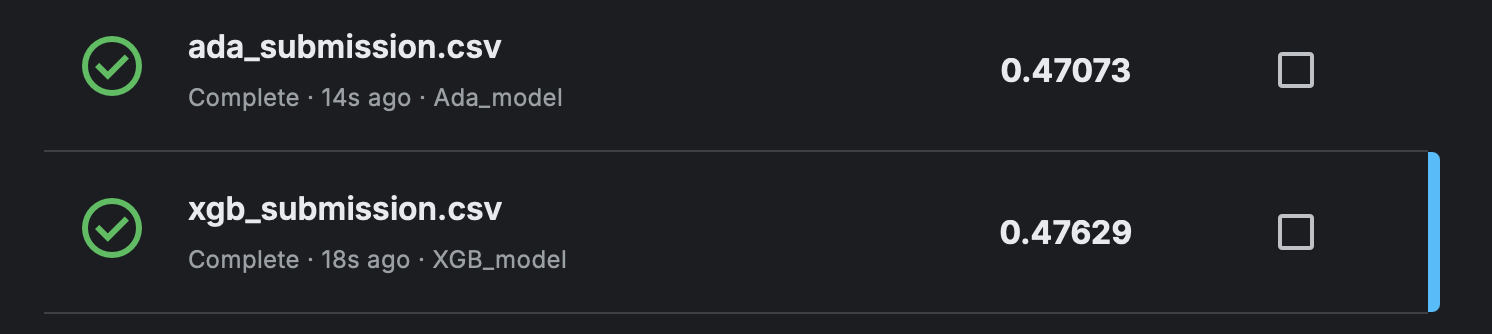

<font color='red'> Summarise your pre-processing steps, models selected (why these?): </font>

In [ ]:
# Add your comment here:


Deleted column `id` since it is just an identifier with no useful information. Then split the dataset into train and validation sets. Normalization was not applied since both models are tree-based and work well without it.

I chose these models since XGBoost is a classic and powerful algorithm for tabular data. Used `eval_metric='aucpr'` as our dataset is imbalanced, and early stopping to prevent overfitting. AdaBoost was selected as I am familiar with how it works and wanted to compare it against XGBoost.

<font color='red'> **(Homework exercise 3- c)** Reaching superiority: tune the above models or train a new one (does not have to be ensemble) such that you beat Mr.Smart (`mr_smart.csv`) benchmark. If one or both of your models from 3-b are already superior to Mr.Smart, then you should beat them instead. In order to claim the point in this exercise, describe the model, data pre-processing steps and report your score (which should be higher than Mr Smart's and your previous' models). **(1.5 points)** </font>

In [7]:
!pip install CatBoost
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 14.2 MB/s eta 0:00:00


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, classification_report
from catboost import CatBoostClassifier
import logging
import optuna
from sklearn.model_selection import StratifiedKFold
optuna.logging.set_verbosity(optuna.logging.WARNING)
from sklearn.base import BaseEstimator, TransformerMixin

In [9]:
log = logging.getLogger(__name__)

In [10]:
X = train.drop(["id", "target"], axis=1)
y = train["target"]
X_test= pd.read_csv('test.csv').drop(["id"], axis=1)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

In [11]:

class DataPreprocessor(BaseEstimator, TransformerMixin):

    EPS = 1e-9

    DEFAULT_GROUPBY_CONFIGS = [
        ('fc_7', 'f_2', ['mean', 'std']),
        ('fc_9', 'f_2', ['mean']),
        ('fc_8', 'f_2', ['mean']),
    ]

    def __init__(self, groupby_configs: list | None = None) -> None:
        self.groupby_configs = groupby_configs or self.DEFAULT_GROUPBY_CONFIGS

        self.f_cols: list[str] | None = None
        self.cat_features: list[str] | None = None
        self.agg_mappings: dict = {}
        self.global_means: dict = {}

    def fit(self, X: pd.DataFrame, y=None) -> "DataPreprocessor":
        self.f_cols = [c for c in X.columns if c.startswith('f_')]
        self.cat_features = [
            c for c in X.columns
            if c.startswith('fc_') and not c.endswith('_te')
        ]

        for cat_col, num_col, aggs in self.groupby_configs:
            self.agg_mappings[(cat_col, num_col)] = (
                X.groupby(cat_col)[num_col].agg(aggs)
            )
            self.global_means[num_col] = X[num_col].mean()

        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if self.f_cols is None:
            raise ValueError("Call fit() before transform().")

        df = X.copy()

        df = self._add_aggregate_features(df)
        df = self._add_interaction_features(df)
        df = self._add_groupby_features(df)

        return df

    def _add_aggregate_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df['f_sum']  = df[self.f_cols].sum(axis=1)
        df['f_mean'] = df[self.f_cols].mean(axis=1)
        df['f_max']  = df[self.f_cols].max(axis=1)
        df['f_min']  = df[self.f_cols].min(axis=1)
        df['f_std']  = df[self.f_cols].std(axis=1)
        return df

    def _add_interaction_features(self, df: pd.DataFrame) -> pd.DataFrame:
        df['f_2_mul_f_10']   = df['f_2'] * df['f_10']
        df['f_2_div_f_10']   = df['f_2'] / (df['f_10'] + self.EPS)
        df['f_2_minus_f_10'] = df['f_2'] - df['f_10']
        return df

    def _add_groupby_features(self, df: pd.DataFrame) -> pd.DataFrame:
        for cat_col, num_col, aggs in self.groupby_configs:
            mapping      = self.agg_mappings[(cat_col, num_col)]
            global_mean  = self.global_means[num_col]

            for agg_name in aggs:
                new_col    = f'{num_col}_{agg_name}_by_{cat_col}'
                fallback   = global_mean if agg_name == 'mean' else 0
                df[new_col] = df[cat_col].map(mapping[agg_name]).fillna(fallback)

            if 'mean' in aggs:
                mean_col = f'{num_col}_mean_by_{cat_col}'
                diff_col = f'{num_col}_diff_from_{cat_col}_mean'
                df[diff_col] = df[num_col] - df[mean_col]

        return df

In [17]:
log = logging.getLogger(__name__)


class ModelTrainer:
    _OPTUNA_SPACE = {
        "iterations":          (300, 700),
        "learning_rate":       (0.001, 0.1),
        "depth":               (4, 10),
        "l2_leaf_reg":         (1.0, 10.0),
        "bagging_temperature": (0.0, 1.0),
        "border_count":        (32, 255),
    }

    _FAST_THRESHOLD_RANGE  = (0.50, 0.80, 0.05)
    _FINAL_THRESHOLD_RANGE = (0.6, 0.70, 0.001)

    def __init__(
        self,
        cat_cols: list[str],
        random_seed: int = 42,
    ) -> None:
        self.cat_features  = cat_cols
        self.random_seed   = random_seed

        self.best_params: dict | None = None
        self.models: list[CatBoostClassifier] = []
        self.best_threshold: float = 0.5
        self.best_f1: float = 0.0

    def tune_hyperparameters(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        n_trials: int = 50,
        val_size: float = 0.2,
    ) -> dict:
        X_tr, X_vl, y_tr, y_vl = train_test_split(
            X, y,
            test_size=val_size,
            random_state=self.random_seed,
            stratify=y,
        )

        def objective(trial: optuna.Trial) -> float:
            params = self._build_params(trial)

            model = CatBoostClassifier(**params)
            model.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))

            proba      = model.predict_proba(X_vl)[:, 1]
            thresholds = np.arange(*self._FAST_THRESHOLD_RANGE)
            _, f1      = self._optimize_threshold(y_vl, proba, thresholds)
            return f1

        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials)

        self.best_params = study.best_params
        log.info("Best Optuna Macro F1: %.4f", study.best_value)
        return self.best_params

    def train(
        self,
        X: pd.DataFrame,
        y: pd.Series,
        val_size: float = 0.2,
    ) -> tuple[pd.Series, np.ndarray]:
        if self.best_params is None:
            raise ValueError("Call tune_hyperparameters() before train().")

        X_tr, X_vl, y_tr, y_vl = train_test_split(
            X, y,
            test_size=val_size,
            random_state=self.random_seed,
            stratify=y,
        )

        model = self._build_final_model()
        model.fit(X_tr, y_tr, eval_set=(X_vl, y_vl))

        self.models = [model]
        log.info("Model trained.")

        return y_vl, model.predict_proba(X_vl)[:, 1]

    def find_best_threshold(
        self,
        y_true: pd.Series,
        val_preds: np.ndarray,
    ) -> float:
        thresholds = np.arange(*self._FINAL_THRESHOLD_RANGE)
        self.best_threshold, self.best_f1 = self._optimize_threshold(
            y_true, val_preds, thresholds,
        )

        log.info("Val ROC-AUC:    %.4f", roc_auc_score(y_true, val_preds))
        log.info("Val Macro F1:   %.4f", self.best_f1)
        log.info("Best threshold: %.3f", self.best_threshold)
        return self.best_threshold

    def predict(self, X_test: pd.DataFrame) -> np.ndarray:

        return (self.predict_proba(X_test) > self.best_threshold).astype(int)

    def predict_proba(self, X_test: pd.DataFrame) -> np.ndarray:
        if not self.models:
            raise ValueError("Call train() before predict_proba().")

        return self.models[0].predict_proba(X_test)[:, 1]

    def _build_params(self, trial: optuna.Trial) -> dict:
        space = self._OPTUNA_SPACE
        return {
            "task_type": "GPU",
            "devices": "0",
            "iterations":            trial.suggest_int("iterations",          *space["iterations"]),
            "learning_rate":         trial.suggest_float("learning_rate",     *space["learning_rate"]),
            "depth":                 trial.suggest_int("depth",               *space["depth"]),
            "l2_leaf_reg":           trial.suggest_float("l2_leaf_reg",       *space["l2_leaf_reg"]),
            "bagging_temperature":   trial.suggest_float("bagging_temperature", *space["bagging_temperature"]),
            "border_count":          trial.suggest_int("border_count",        *space["border_count"]),
            "cat_features":          self.cat_features,
            "auto_class_weights":    "Balanced",
            "early_stopping_rounds": 30,
            "random_seed":           self.random_seed,
            "verbose":               0,
        }

    def _build_final_model(self) -> CatBoostClassifier:
        return CatBoostClassifier(
            **self.best_params,
            task_type="GPU",
            cat_features=self.cat_features,
            auto_class_weights="Balanced",
            early_stopping_rounds=30,
            random_seed=self.random_seed,
            verbose=0,
        )

    @staticmethod
    def _optimize_threshold(
        y_true: pd.Series,
        probabilities: np.ndarray,
        thresholds: np.ndarray,
    ) -> tuple[float, float]:
        best_thresh, best_f1 = 0.5, 0.0

        for t in thresholds:
            f1 = f1_score(
                y_true,
                (probabilities > t).astype(int),
                average="macro",
            )
            if f1 > best_f1:
                best_f1, best_thresh = f1, t

        return best_thresh, best_f1

In [13]:
class FeatureSelector(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        cat_features: list[str],
        threshold: float = 0.90,
        importance_iterations: int = 100,
        random_seed: int = 42,
    ) -> None:
        self.cat_features           = cat_features
        self.threshold              = threshold
        self.importance_iterations  = importance_iterations
        self.random_seed            = random_seed

        self.important_features: list[str] | None = None

    def fit(self, X: pd.DataFrame, y: pd.Series) -> "FeatureSelector":
        importances = self._get_feature_importances(X, y)
        self.important_features = self._select_by_cumulative_importance(importances)
        self._ensure_cat_features_included(X)

        log.info(
            "FeatureSelector: kept %d / %d features (threshold=%.2f).",
            len(self.important_features),
            X.shape[1],
            self.threshold,
        )
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        if self.important_features is None:
            raise ValueError("Call fit() before transform().")

        return X[self.important_features].copy()

    def _get_feature_importances(self, X: pd.DataFrame, y: pd.Series,
    ) -> pd.Series:
        model = CatBoostClassifier(
            iterations=self.importance_iterations,
            cat_features=self.cat_features,
            random_seed=self.random_seed,
            verbose=0,
        )
        model.fit(X, y)

        importances = pd.Series(
            model.get_feature_importance(),
            index=X.columns,
        )
        return importances.sort_values(ascending=False)

    def _select_by_cumulative_importance(
        self,
        sorted_importances: pd.Series,
    ) -> list[str]:
        cumulative = sorted_importances.cumsum() / sorted_importances.sum()
        return cumulative[cumulative <= self.threshold].index.tolist()

    def _ensure_cat_features_included(self, X: pd.DataFrame) -> None:
        for col in self.cat_features:
            if col in X.columns and col not in self.important_features:
                self.important_features.append(col)
                log.debug("FeatureSelector: force-kept cat feature '%s'.", col)

In [18]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
)


preprocessor  = DataPreprocessor()
X_train_clean = preprocessor.fit_transform(X_train)
X_val_clean   = preprocessor.transform(X_val)
X_test_clean  = preprocessor.transform(X_test)


selector      = FeatureSelector(cat_features=preprocessor.cat_features, threshold=0.90)
X_train_final = selector.fit_transform(X_train_clean, y_train)
X_val_final   = selector.transform(X_val_clean)
X_test_final  = selector.transform(X_test_clean)

final_cat_features = [c for c in preprocessor.cat_features if c in X_train_final.columns]

trainer   = ModelTrainer(cat_cols=final_cat_features, random_seed=42)
trainer.tune_hyperparameters(X_train_final, y_train, n_trials=20)

y_val_part, val_preds = trainer.train(X_train_final, y_train)
trainer.find_best_threshold(y_val_part, val_preds)

predictions = trainer.predict(X_test_final)

submission = pd.read_csv("sample_submission.csv")
submission["target"] = predictions.astype(int)
submission.to_csv("catboost_optuna_submission.csv", index=False)

!kaggle competitions submit -c ml-kse-2026 -f catboost_optuna_submission.csv -m "Velikij_i_mogychij_CatBoost"

100% 222k/222k [00:00<00:00, 384kB/s]
Successfully submitted to ML@KSE2026

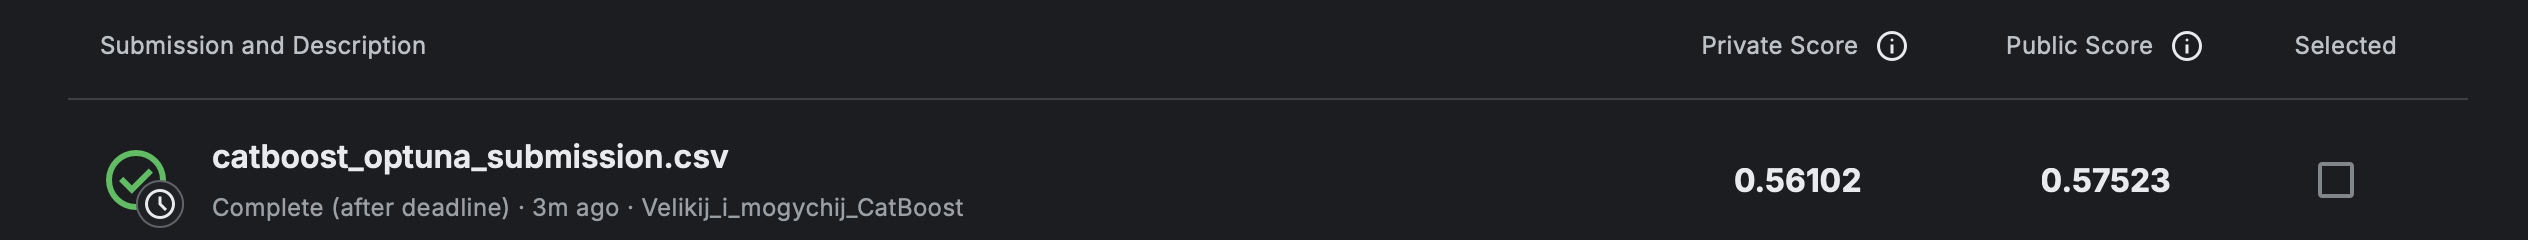

<font color='red'> Summarise your pre-processing steps, models selected (why these?), and the "special sauce" (what you changed compared to 3-b) below: </font>

In [ ]:
# Add your comment here:
#  I will beter tell you in real

# Bonus exercises
*(NB, these are optional exercises!)*


##Bonus exercise 1 (1 bonus point): Interim Champion

<font color='red'> If at any point of time your submission lended at the top of the **public leaderboard** from the Kaggle competition (Exercise 3), take a screenshot of this remarkable achievement before it is too late and somebody else did not knock it off. Post this screenshot below (add a picture). Describe your solution below (do not have to write too much, just the main idea). You can only get this point once.

In [ ]:
# Add your comment here:


## Bonus exercise 2 (up to 3 bonus points): Top Perfomer Challenge

<font color='red'> You are encouraged to compete for the top three places in the Kaggle competition described in Exercise 3. So, **3 points** for the first place, **2 points** for the second place and **1.5 points** for the third place.

<font color='red'> To receive the bonus points, you must finish in the top three of the **private leaderboard** and maintain your position throughout the competition. The end of the competition is 04.04.2026 23:59:59.</font>

## Bonus exercise 3 (up to 3 bonus points depending on presentation): Discrete AdaBoost from scratch



<font color='red'> In the class we have discussed a simplified version of the AdaBoost, the goal of this task is to implement an unabrdiged version of the Discrete AdaBoost classifier following the instructions from the paper [Friedman et al (2000)](https://hastie.su.domains/Papers/AdditiveLogisticRegression/alr.pdf). In a nutshell, AdaBoost classifier assigns initial weights to training examples, fits a weak classifier, and updates the data and classifier weights based on classification accuracy. The process is repeated for each weak estimator. The final strong classifier combines weak classifiers with different weights.</font>

<font color='red'> Implement AdaBoost classifier.

Tips:

- use `DecisionTreeClassifier` from `sklearn` as a weak classifier
- avoid division by zero
- pay attention to the format of data labels.</font>



In [ ]:
class AdaBoost:
  def __init__(self, n_estimators=50):
    self.n_estimators = n_estimators
    self.estimator_weights = []
    self.models = []

  def fit(self, X, y):
    ##### YOUR CODE STARTS #####
    ...
    ##### YOUR CODE ENDS #####

  def predict(self, X):
    ##### YOUR CODE STARTS #####
    ...
    ##### YOUR CODE ENDS #####



<font color='red'> Test your model on the dataset from exercise 3. Report accuracy on the test set and observe how the performance changes with the different number of estimators.</font>

In [ ]:
##### YOUR CODE STARTS #####
...
##### YOUR CODE ENDS #####

<font color='red'> Use sklearn implementation of AdaBoost classifier with the same parameters as you used for your implementation. Report accuracy on the test set as well. </font>

In [ ]:
##### YOUR CODE STARTS #####
...
##### YOUR CODE ENDS #####

<font color='red'> Report difference in results, if there are any. Explain why sklearn's model behaves differently, you might want to take a look at sklearn's [code](https://github.com/scikit-learn/scikit-learn/blob/093e0cf14/sklearn/ensemble/_weight_boosting.py#L341) :)</font>

<font color='red'> Your answer:</font>

# Comments (optional feedback to the course instructors)
Here, please, leave your comments regarding the practice session, possibly answering the following questions:

* how much time did you spend on this homework?
* was it too hard/easy for you?
* what would you suggest to add or remove?
* anything else you would like to tell us

Your comments:

# <font color='red'>  End of the homework. Please don't delete this cell.</font>